# ✦ StudentLife Screen-Use Proxy Analysis

## Finding the Minimum and Maximum Phone-Based Screen-Use Range

This notebook analyzes the **Zenodo RData version of the StudentLife dataset** to estimate a screen-use range from phone-lock data.

The original Dartmouth download link timed out during our first attempt, so we use the Zenodo RData version instead. This version is not a small sample dataset. It is the StudentLife dataset converted into compressed `.Rds` tables, which makes it easier to download and process.

The dataset does not directly provide a simple variable called “screen time in hours.”
Instead, it provides records of when the phone was locked.

Because of this, we calculate a **screen-use proxy** using the following idea:

> If the phone was locked, it was probably not being used.
> If the phone was not locked, it may have been available for use.

The main formula used in this analysis is:

**screen_use_proxy_hours = 24 - locked_hours_per_day**

This means that the result should not be interpreted as perfect screen time.
It is an approximation based on phone-lock behaviour.

In this notebook, we will:

1. Download and extract the Zenodo RData version of the StudentLife dataset.
2. Locate the phone-lock `.Rds` file.
3. Load the phone-lock data into Python.
4. Calculate locked-phone time per participant per day.
5. Convert locked time into a screen-use proxy.
6. Find the minimum and maximum observed screen-use proxy values.


---

# 1. ✧ Importing the Tools

Before we begin working with the dataset, we need to import the Python libraries used in this notebook.

Each library has a specific role in the analysis:

| Library    | Purpose                                                                  |
| ---------- | ------------------------------------------------------------------------ |
| `pathlib`  | Helps us work with folders and file paths in a clean way                 |
| `requests` | Downloads the dataset from the internet                                  |
| `zipfile`  | Extracts the downloaded `.zip` file                                      |
| `pandas`   | Loads, cleans, and analyzes the dataset                                  |
| `tqdm`     | Shows progress bars while the notebook processes data                    |
| `pyreadr`  | Allows Python to read `.Rds` files from the RData version of the dataset |

Together, these tools allow us to download the dataset, open the phone-lock data, calculate daily locked-phone time, and estimate the screen-use proxy.

> In simple terms: this step prepares the notebook’s toolbox.


In [1]:
from pathlib import Path
import requests
import zipfile
import pandas as pd
from tqdm.auto import tqdm
import pyreadr

---

# 2. ✧ Setting Up the Dataset Paths

In this step, we decide where the StudentLife dataset will be stored on the computer.

Instead of using the original Dartmouth `.tar.bz2` download, this notebook uses the Zenodo RData version:

**dataset_rds.zip**

After downloading, the `.zip` file will be extracted into a local folder so that Python can access the `.Rds` tables inside it.

This notebook uses three main paths:

| Path variable  | Meaning                                                    |
| -------------- | ---------------------------------------------------------- |
| `DATA_URL`     | The Zenodo link where the RData version is downloaded from |
| `ARCHIVE_PATH` | The location where the compressed `.zip` file is saved     |
| `EXTRACT_DIR`  | The folder where the dataset will be extracted             |

This keeps the project organized, because all downloaded and extracted files stay inside one main folder called:

**data**

> In simple terms: this step prepares the storage shelves before we bring in the dataset.


In [2]:
DATA_URL = "https://zenodo.org/records/3529253/files/dataset_rds.zip?download=1"

DATA_DIR = Path("data")
ARCHIVE_PATH = DATA_DIR / "dataset_rds.zip"
EXTRACT_DIR = DATA_DIR / "studentlife_rds"

DATA_DIR.mkdir(exist_ok=True)
EXTRACT_DIR.mkdir(exist_ok=True)

print("Archive will be saved to:", ARCHIVE_PATH)
print("Dataset will be extracted to:", EXTRACT_DIR)

Archive will be saved to: data\dataset_rds.zip
Dataset will be extracted to: data\studentlife_rds


---

# 3. ✧ Downloading the Zenodo RData Version

In this step, we download the Zenodo RData version of the StudentLife dataset.

The original Dartmouth download timed out, so this version is more practical for the analysis.
It contains the dataset in compressed `.Rds` files, which are easier to process than the original folder structure.

The downloaded file is:

**dataset_rds.zip**

To make the process safer, the code first checks whether the file has already been downloaded.

This means:

| Situation                           | What the code does              |
| ----------------------------------- | ------------------------------- |
| The dataset file already exists     | The notebook skips the download |
| The dataset file does not exist yet | The notebook downloads it       |

A progress bar is shown during the download, so we can see whether the process is still running.

> In simple terms: this step brings the easier-to-use version of the dataset into our project folder.


In [3]:
def download_file(url, destination):
    if destination.exists():
        print("File already exists, skipping download:")
        print(destination)
        return

    print("Downloading dataset...")
    response = requests.get(url, stream=True, timeout=120)
    response.raise_for_status()

    total_size = int(response.headers.get("content-length", 0))

    with open(destination, "wb") as file, tqdm(
        total=total_size,
        unit="B",
        unit_scale=True,
        desc="Downloading"
    ) as progress_bar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                file.write(chunk)
                progress_bar.update(len(chunk))

    print("Download finished!")


download_file(DATA_URL, ARCHIVE_PATH)

Downloading:   0%|          | 0.00/230M [00:00<?, ?B/s]

Download finished!


---

# 4. ✧ Extracting the RData Dataset

After downloading the dataset, we need to extract the `.zip` file.

The extracted folder contains the StudentLife data as `.Rds` tables.
These are R data files, but we can read them in Python using the `pyreadr` library.

For this analysis, the most important file is the phone-lock table, which should be named something like:

**phonelock.Rds**

This file contains the phone-lock records used to estimate screen-use proxy values.

> In simple terms: this step opens the dataset box so we can use the files inside.


In [4]:
if any(EXTRACT_DIR.iterdir()):
    print("Extract folder is not empty, so extraction may already be done.")
else:
    print("Extracting dataset...")
    with zipfile.ZipFile(ARCHIVE_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Extraction finished!")

Extracting dataset...
Extraction finished!


---

# 5. ✧ Locating the Phone-Lock Data File

Now that the dataset has been extracted, we need to find the specific file that contains the phone-lock data.

In the RData version of the StudentLife dataset, the phone-lock data should be stored in a file named:

**phonelock.Rds**

This file is important because it tells us when the phone was locked.

A phone-lock record usually contains a start time and an end time.
This allows us to calculate how long the phone was locked.

The general idea is:

**locked_time = end - start**

Later, we will use this locked time to estimate screen use:

**screen_use_proxy_hours = 24 - locked_hours_per_day**

> In simple terms: this step finds the exact file that contains the phone-lock information we need.


In [5]:
phonelock_files = list(EXTRACT_DIR.rglob("phonelock.Rds"))

print("Found phonelock files:")
for file in phonelock_files:
    print(file)

PHONELOCK_FILE = phonelock_files[0]
print("\nUsing:", PHONELOCK_FILE)

Found phonelock files:
data\studentlife_rds\dataset_rds\sensing\phonelock.Rds

Using: data\studentlife_rds\dataset_rds\sensing\phonelock.Rds


---

# 6. ✧ Loading the Phone-Lock Data

In this step, we load the phone-lock `.Rds` file into Python.

The file is originally stored in an R format, so we use the `pyreadr` library to open it.

After loading the file, we convert it into a pandas dataframe.
A dataframe is like a table: it has rows, columns, and values.

This step helps us check:

| Check          | Meaning                                     |
| -------------- | ------------------------------------------- |
| Number of rows | How many phone-lock records are in the file |
| Column names   | What variables are available in the data    |
| First rows     | A quick preview of the dataset              |

The most important columns should describe when each phone-lock period started and ended.

> In simple terms: this step opens the phone-lock table so we can inspect and use it.

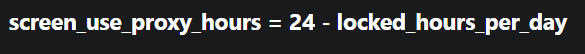

In [6]:
result = pyreadr.read_r(PHONELOCK_FILE)

# pyreadr returns a dictionary.
# We take the first table inside it and store it as a pandas dataframe.
phonelock_df = next(iter(result.values()))

print("Rows:", len(phonelock_df))
print("Columns:", phonelock_df.columns.tolist())

phonelock_df.head()

Rows: 9275
Columns: ['start_timestamp', 'end_timestamp', 'uid']


,start_timestamp,end_timestamp,uid
0,1.364359e+09,1.364365e+09,0
1,1.364366e+09,1.364382e+09,0
2,1.364386e+09,1.364391e+09,0
3,1.364406e+09,1.364411e+09,0
4,1.364426e+09,1.364429e+09,0


---

# 7. ✧ Preparing the Phone-Lock Columns

Before calculating locked-phone time, we need to make sure the column names are easy to use.

Datasets sometimes store column names with different spelling, capitalization, or spacing.
For example, a column could be called:

* `start`
* `Start`
* `start_time`
* `start timestamp`

To avoid problems, this step cleans the column names by making them lowercase and replacing spaces with underscores.

After that, the code searches for the two most important columns:

| Column  | Meaning                        |
| ------- | ------------------------------ |
| `start` | When a phone-lock period began |
| `end`   | When a phone-lock period ended |

These two columns are needed because locked time is calculated as:

**locked_time = end - start**

> In simple terms: this step makes sure Python knows which columns mark the beginning and end of each locked-phone period.


In [7]:
# Make a copy so the original loaded data stays safe
phonelock_df = phonelock_df.copy()

# Clean column names
phonelock_df.columns = [
    str(col).strip().lower().replace(" ", "_")
    for col in phonelock_df.columns
]

print("Cleaned column names:")
print(phonelock_df.columns.tolist())

# Possible names for the start and end columns
possible_start_columns = ["start", "start_time", "start_timestamp", "begin"]
possible_end_columns = ["end", "end_time", "end_timestamp", "stop"]

# Find the actual start and end columns in this dataset
start_col = next(
    (col for col in possible_start_columns if col in phonelock_df.columns),
    None
)

end_col = next(
    (col for col in possible_end_columns if col in phonelock_df.columns),
    None
)

if start_col is None or end_col is None:
    raise ValueError(
        "Could not find start/end columns. "
        f"Available columns are: {phonelock_df.columns.tolist()}"
    )

print("Start column found:", start_col)
print("End column found:", end_col)

Cleaned column names:
['start_timestamp', 'end_timestamp', 'uid']
Start column found: start_timestamp
End column found: end_timestamp


---

# 8. ✧ Checking Users and Calculating Phone-Lock Intervals

In this step, we begin turning the raw phone-lock records into meaningful time values.

The phone-lock table is not organized as one column per user.
Instead, it is organized as many rows of phone-lock events.

Each row represents one phone-lock interval:

| Column  | Meaning                                        |
| ------- | ---------------------------------------------- |
| `uid`   | Which participant / user the record belongs to |
| `start` | When the phone-lock period began               |
| `end`   | When the phone-lock period ended               |

To calculate how long the phone was locked, we use:

**locked_interval = end - start**

This gives the length of each individual locked-phone period.

We also count how many unique users appear in the phone-lock data.
This helps us understand how many participants are included in this part of the dataset.

> In simple terms: this step checks how many users we have and calculates the length of each phone-lock event.


In [8]:
# Possible names for the user / participant column
possible_uid_columns = ["uid", "user", "user_id", "participant", "participant_id", "id"]

uid_col = next(
    (col for col in possible_uid_columns if col in phonelock_df.columns),
    None
)

if uid_col is None:
    raise ValueError(
        "Could not find a user/participant column. "
        f"Available columns are: {phonelock_df.columns.tolist()}"
    )

print("User column found:", uid_col)

# Count users before cleaning
total_users_raw = phonelock_df[uid_col].nunique()
print("Total unique users in raw phone-lock data:", total_users_raw)


def convert_to_datetime(series):
    """
    Converts a timestamp column into datetime format.

    The StudentLife timestamps may be stored as Unix seconds,
    Unix milliseconds, or already as datetime values.
    This helper function tries to handle those cases safely.
    """
    if pd.api.types.is_datetime64_any_dtype(series):
        return pd.to_datetime(series, utc=True)

    numeric_values = pd.to_numeric(series, errors="coerce")

    # Decide whether timestamps are probably in seconds or milliseconds
    median_value = numeric_values.dropna().median()

    if median_value > 1_000_000_000_000:
        unit = "ms"
    else:
        unit = "s"

    return pd.to_datetime(numeric_values, unit=unit, utc=True, errors="coerce")


# Convert start and end into datetime values
phonelock_df["start_datetime"] = convert_to_datetime(phonelock_df[start_col])
phonelock_df["end_datetime"] = convert_to_datetime(phonelock_df[end_col])

# Remove rows where start or end could not be read
phonelock_clean = phonelock_df.dropna(
    subset=[uid_col, "start_datetime", "end_datetime"]
).copy()

# Remove impossible rows where the phone-lock end time is before the start time
phonelock_clean = phonelock_clean[
    phonelock_clean["end_datetime"] > phonelock_clean["start_datetime"]
].copy()

# Calculate how long each locked interval lasted
phonelock_clean["locked_interval_hours"] = (
    phonelock_clean["end_datetime"] - phonelock_clean["start_datetime"]
).dt.total_seconds() / 3600

# Count users after cleaning
total_users_clean = phonelock_clean[uid_col].nunique()

print("Valid phone-lock intervals:", len(phonelock_clean))
print("Total unique users after cleaning:", total_users_clean)

phonelock_clean[[uid_col, "start_datetime", "end_datetime", "locked_interval_hours"]].head()

User column found: uid
Total unique users in raw phone-lock data: 49
Valid phone-lock intervals: 9275
Total unique users after cleaning: 49


,uid,start_datetime,end_datetime,locked_interval_hours
0,0,2013-03-27 04:36:32+00:00,2013-03-27 06:13:27+00:00,1.615278
1,0,2013-03-27 06:26:05+00:00,2013-03-27 10:58:53+00:00,4.546667
2,0,2013-03-27 12:12:13+00:00,2013-03-27 13:30:08+00:00,1.298611
3,0,2013-03-27 17:46:18+00:00,2013-03-27 19:04:09+00:00,1.297500
4,0,2013-03-27 23:05:58+00:00,2013-03-28 00:11:11+00:00,1.086944


---

# 9. ✧ Splitting Phone-Lock Intervals by Day

Some phone-lock intervals can cross midnight.

For example, a phone could be locked from:

**23:00 → 07:00**

This is one continuous locked interval, but it belongs to two different days:

| Day   |           Locked time |
| ----- | --------------------: |
| Day 1 |  23:00–00:00 = 1 hour |
| Day 2 | 00:00–07:00 = 7 hours |

This step splits each phone-lock interval into daily pieces.
That way, every locked-hour segment is assigned to the correct user and date.

This is necessary before we calculate daily locked time, because our final screen-use proxy is based on:

**locked_hours_per_day**

and then:

**screen_use_proxy_hours = 24 - locked_hours_per_day**

> In simple terms: this step carefully cuts long phone-lock periods at midnight so each day gets the correct amount of locked time.


In [9]:
LOCAL_TIMEZONE = "America/New_York"


def split_interval_by_day(row):
    """
    Splits one phone-lock interval into daily pieces.

    This is needed because one phone-lock interval can cross midnight.
    For example: 23:00 to 07:00 should be split across two dates.
    """
    uid = row[uid_col]

    start = row["start_datetime"].tz_convert(LOCAL_TIMEZONE)
    end = row["end_datetime"].tz_convert(LOCAL_TIMEZONE)

    pieces = []
    current = start

    while current < end:
        # Midnight at the start of the next day
        next_midnight = current.normalize() + pd.Timedelta(days=1)

        # The segment ends either at midnight or at the real interval end
        segment_end = min(end, next_midnight)

        locked_seconds = (segment_end - current).total_seconds()

        pieces.append({
            "uid": uid,
            "date": current.date(),
            "segment_start": current,
            "segment_end": segment_end,
            "locked_seconds": locked_seconds
        })

        current = segment_end

    return pieces


daily_pieces = []

for _, row in tqdm(
    phonelock_clean.iterrows(),
    total=len(phonelock_clean),
    desc="Splitting intervals by day"
):
    daily_pieces.extend(split_interval_by_day(row))

daily_lock_pieces = pd.DataFrame(daily_pieces)

print("Daily lock pieces created:", len(daily_lock_pieces))
print("Unique users in daily pieces:", daily_lock_pieces["uid"].nunique())
print("Date range:", daily_lock_pieces["date"].min(), "to", daily_lock_pieces["date"].max())

daily_lock_pieces.head()

Splitting intervals by day:   0%|          | 0/9275 [00:00<?, ?it/s]

Daily lock pieces created: 10333
Unique users in daily pieces: 49
Date range: 2013-03-26 to 2013-05-31


,uid,date,segment_start,segment_end,locked_seconds
0,0,2013-03-27,2013-03-27 00:36:32-04:00,2013-03-27 02:13:27-04:00,5815.0
1,0,2013-03-27,2013-03-27 02:26:05-04:00,2013-03-27 06:58:53-04:00,16368.0
2,0,2013-03-27,2013-03-27 08:12:13-04:00,2013-03-27 09:30:08-04:00,4675.0
3,0,2013-03-27,2013-03-27 13:46:18-04:00,2013-03-27 15:04:09-04:00,4671.0
4,0,2013-03-27,2013-03-27 19:05:58-04:00,2013-03-27 20:11:11-04:00,3913.0


---

# 10. ✧ Combining Lock Intervals into Daily Locked Time

Now that every phone-lock interval has been split into the correct date, we can combine the intervals.

At this stage, each row still represents only one piece of locked-phone time.

To estimate daily phone use, we need to group the data by:

| Grouping variable | Meaning                            |
| ----------------- | ---------------------------------- |
| `uid`             | The participant / user             |
| `date`            | The day the locked time belongs to |

Then we add all locked seconds for each user on each date.

This gives us:

**locked_hours_per_day**

Each row in the new table represents one **participant-day**.

A participant-day means:

> one participant on one specific date

For example, if one user has phone-lock data for 10 different days, that user can contribute 10 participant-days.

This is useful because the final screen-use proxy is calculated per day:

**screen_use_proxy_hours = 24 - locked_hours_per_day**

> In simple terms: this step combines all lock pieces into one daily locked-time value for each user.


In [10]:
# Combine all locked-time pieces for the same user and date
daily_summary = (
    daily_lock_pieces
    .groupby(["uid", "date"], as_index=False)["locked_seconds"]
    .sum()
)

# Convert seconds into hours
daily_summary["locked_hours_per_day"] = daily_summary["locked_seconds"] / 3600

# Count impossible values before clipping
days_above_24 = (daily_summary["locked_hours_per_day"] > 24).sum()

print("Total participant-days:", len(daily_summary))
print("Unique users:", daily_summary["uid"].nunique())
print("Days with more than 24 locked hours before clipping:", days_above_24)

# Clip locked hours to the possible daily range: 0 to 24 hours
daily_summary["locked_hours_per_day"] = daily_summary["locked_hours_per_day"].clip(
    lower=0,
    upper=24
)

print("\nLocked hours per day summary:")
display(daily_summary["locked_hours_per_day"].describe())

daily_summary.head()

Total participant-days: 2571
Unique users: 49
Days with more than 24 locked hours before clipping: 3

Locked hours per day summary:


count    2571.000000
mean       11.255735
std         6.008784
min         0.009444
25%         6.709722
50%        10.896111
75%        15.789028
max        24.000000
Name: locked_hours_per_day, dtype: float64

,uid,date,locked_seconds,locked_hours_per_day
0,0,2013-03-27,35442.0,9.845000
1,0,2013-03-28,5161.0,1.433611
2,0,2013-03-29,45783.0,12.717500
3,0,2013-03-30,32712.0,9.086667
4,0,2013-03-31,61902.0,17.195000


---

# 11. ✧ Calculating the Screen-Use Proxy

Now that we have calculated how many hours each participant’s phone was locked per day, we can estimate daily screen use.

The StudentLife phone-lock data does not directly tell us exact screen time.
Instead, it tells us when the phone was locked.

So we estimate screen use using this formula:

**screen_use_proxy_hours = 24 - locked_hours_per_day**

This means:

|        Locked time |            Screen-use proxy |
| -----------------: | --------------------------: |
|  More locked hours |  Lower estimated screen use |
| Fewer locked hours | Higher estimated screen use |

For example, if a participant’s phone was locked for 16 hours in one day:

**screen_use_proxy_hours = 24 - 16 = 8 hours**

This means the phone was not recorded as locked for 8 hours that day.

This is why the variable is called a **proxy**.
It estimates possible phone/screen use, but it is not perfect measured screen time.

> In simple terms: this step turns daily locked-phone time into estimated daily screen-use time.


In [11]:
# Calculate the screen-use proxy
daily_summary["screen_use_proxy_hours"] = 24 - daily_summary["locked_hours_per_day"]

# Keep the screen-use proxy inside the possible daily range
daily_summary["screen_use_proxy_hours"] = daily_summary["screen_use_proxy_hours"].clip(
    lower=0,
    upper=24
)

print("Screen-use proxy calculated.")
print("Total participant-days:", len(daily_summary))
print("Unique users:", daily_summary["uid"].nunique())

print("\nScreen-use proxy summary:")
display(daily_summary["screen_use_proxy_hours"].describe())

daily_summary.head()

Screen-use proxy calculated.
Total participant-days: 2571
Unique users: 49

Screen-use proxy summary:


count    2571.000000
mean       12.744265
std         6.008784
min         0.000000
25%         8.210972
50%        13.103889
75%        17.290278
max        23.990556
Name: screen_use_proxy_hours, dtype: float64

,uid,date,locked_seconds,locked_hours_per_day,screen_use_proxy_hours
0,0,2013-03-27,35442.0,9.845000,14.155000
1,0,2013-03-28,5161.0,1.433611,22.566389
2,0,2013-03-29,45783.0,12.717500,11.282500
3,0,2013-03-30,32712.0,9.086667,14.913333
4,0,2013-03-31,61902.0,17.195000,6.805000


---

# 12. ✧ Finding the Minimum and Maximum Screen-Use Proxy

Now that the daily screen-use proxy has been calculated, we can find the main range of the variable.

The screen-use proxy is stored in:

**screen_use_proxy_hours**

This value represents the estimated number of hours per day that the phone was not recorded as locked.

In this step, we calculate:

| Statistic | Meaning                                 |
| --------- | --------------------------------------- |
| Minimum   | Lowest observed daily screen-use proxy  |
| Maximum   | Highest observed daily screen-use proxy |
| Mean      | Average daily screen-use proxy          |
| Median    | Middle value of daily screen-use proxy  |

The minimum and maximum are especially useful for our project because they help define the possible input range for the installation.

However, this is still a **proxy**, not exact screen time.

> In simple terms: this step tells us the lowest and highest estimated screen-use values found in the processed dataset.


In [12]:
# Select the screen-use proxy column
screen = daily_summary["screen_use_proxy_hours"]

# Calculate key statistics
minimum_screen_time = screen.min()
maximum_screen_time = screen.max()
mean_screen_time = screen.mean()
median_screen_time = screen.median()

print("Screen-use proxy statistics")
print("---------------------------")
print("Minimum screen-use proxy:", round(minimum_screen_time, 2), "hours/day")
print("Maximum screen-use proxy:", round(maximum_screen_time, 2), "hours/day")
print("Mean screen-use proxy:", round(mean_screen_time, 2), "hours/day")
print("Median screen-use proxy:", round(median_screen_time, 2), "hours/day")

print("\nFull descriptive statistics:")
stats_table = screen.describe().reset_index()
stats_table.columns = ["Statistic", "Value"]

stats_table["Value"] = stats_table["Value"].round(2)

stats_table

Screen-use proxy statistics
---------------------------
Minimum screen-use proxy: 0.0 hours/day
Maximum screen-use proxy: 23.99 hours/day
Mean screen-use proxy: 12.74 hours/day
Median screen-use proxy: 13.1 hours/day

Full descriptive statistics:


,Statistic,Value
0,count,2571.00
1,mean,12.74
2,std,6.01
3,min,0.00
4,25%,8.21
5,50%,13.10
6,75%,17.29
7,max,23.99


---

# 13. ✧ Calculating Screen-Use Proxy per User

The previous statistics described **participant-days**.

A participant-day means:

**one user on one recorded day**

Now we calculate a user-level summary.

First, we group the daily screen-use proxy values by user.
Then, for each user, we calculate their average daily screen-use proxy.

This gives us one value per user:

**average_screen_use_proxy_per_user**

After that, we calculate the minimum, maximum, mean, and median across users.

This helps us understand how screen-use proxy differs between participants, instead of only looking at all daily records together.

> In simple terms: this step changes the analysis from “all days” to “all users.”


In [13]:
# Calculate each user's average daily screen-use proxy
user_summary = (
    daily_summary
    .groupby("uid", as_index=False)
    .agg(
        average_screen_use_proxy_hours=("screen_use_proxy_hours", "mean"),
        median_screen_use_proxy_hours=("screen_use_proxy_hours", "median"),
        minimum_screen_use_proxy_hours=("screen_use_proxy_hours", "min"),
        maximum_screen_use_proxy_hours=("screen_use_proxy_hours", "max"),
        recorded_days=("date", "nunique")
    )
)

print("User-level summary created.")
print("Total users:", len(user_summary))

user_summary.head()

User-level summary created.
Total users: 49


,uid,average_screen_use_proxy_hours,median_screen_use_proxy_hours,minimum_screen_use_proxy_hours,maximum_screen_use_proxy_hours,recorded_days
0,0,14.266557,13.891111,5.116944,22.890278,61
1,1,9.227217,10.916389,0.140000,22.634444,58
2,10,11.403838,10.744306,1.551111,21.685556,66
3,12,10.825755,10.964722,1.537222,23.860278,67
4,13,14.533218,14.817639,0.000000,23.655278,58


---

# 14. ✧ Summarizing Screen-Use Proxy Across Users

The previous table summarized all **participant-days**.

Now we summarize the data at the **user level**.

Each user now has one main value:

**average_screen_use_proxy_hours**

This value represents that user’s average daily screen-use proxy across all recorded days.

This step calculates descriptive statistics across users, including:

| Statistic | Meaning              |
| --------- | -------------------- |
| Count     | Number of users      |
| Minimum   | Lowest user average  |
| Median    | Middle user average  |
| Mean      | Average across users |
| Maximum   | Highest user average |

This is useful because it shows the range between participants, instead of treating every recorded day as a separate data point.

> In simple terms: this step tells us how much the average screen-use proxy differs from user to user.


In [14]:
# Select the user-level average screen-use proxy column
user_screen = user_summary["average_screen_use_proxy_hours"]

# Create a clean summary table for user-level statistics
user_stats_table = pd.DataFrame({
    "Statistic": [
        "Count",
        "Minimum",
        "25th percentile",
        "Median",
        "Mean",
        "75th percentile",
        "Maximum",
        "Standard deviation"
    ],
    "Value": [
        f"{int(user_screen.count())} users",
        f"{user_screen.min():.2f} hours/day",
        f"{user_screen.quantile(0.25):.2f} hours/day",
        f"{user_screen.median():.2f} hours/day",
        f"{user_screen.mean():.2f} hours/day",
        f"{user_screen.quantile(0.75):.2f} hours/day",
        f"{user_screen.max():.2f} hours/day",
        f"{user_screen.std():.2f} hours/day"
    ],
    "Simple meaning": [
        "Number of users analyzed",
        "Lowest average daily screen-use proxy among users",
        "25% of users were at or below this average",
        "Middle user average",
        "Average of all users’ daily averages",
        "75% of users were at or below this average",
        "Highest average daily screen-use proxy among users",
        "How spread out the user averages are"
    ]
})

print("User-level screen-use proxy statistics")
print("--------------------------------------")

display(user_stats_table)

User-level screen-use proxy statistics
--------------------------------------


,Statistic,Value,Simple meaning
0,Count,49 users,Number of users analyzed
1,Minimum,6.67 hours/day,Lowest average daily screen-use proxy among users
2,25th percentile,11.20 hours/day,25% of users were at or below this average
3,Median,13.16 hours/day,Middle user average
4,Mean,13.09 hours/day,Average of all users’ daily averages
5,75th percentile,15.16 hours/day,75% of users were at or below this average
6,Maximum,19.20 hours/day,Highest average daily screen-use proxy among u...
7,Standard deviation,2.76 hours/day,How spread out the user averages are


### Daily Screen-Use Proxy Distribution

This chart shows the distribution of the screen-use proxy across all participant-days.

Each value represents one user on one recorded day.
This helps show how the daily screen-use proxy values are spread across the dataset.

The dashed lines mark the mean and the median.

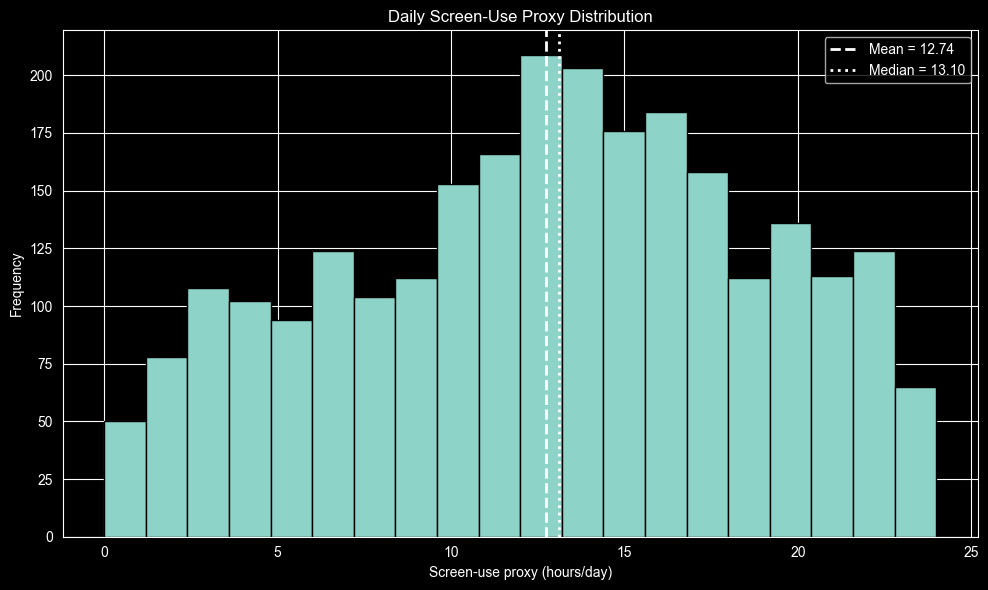

In [15]:
import matplotlib.pyplot as plt

# Daily participant-day distribution
daily_screen = daily_summary["screen_use_proxy_hours"].dropna()

plt.figure(figsize=(10, 6))
plt.hist(daily_screen, bins=20, edgecolor="black")

plt.axvline(daily_screen.mean(), linestyle="--", linewidth=2, label=f"Mean = {daily_screen.mean():.2f}")
plt.axvline(daily_screen.median(), linestyle=":", linewidth=2, label=f"Median = {daily_screen.median():.2f}")

plt.title("Daily Screen-Use Proxy Distribution")
plt.xlabel("Screen-use proxy (hours/day)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()

plt.savefig("daily_screen_use_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### User-Level Screen-Use Proxy Distribution

This chart shows the distribution of the average daily screen-use proxy across users.

Each value represents one user’s average daily screen-use proxy across their recorded days.
This helps show how screen-use proxy differs between participants.

The dashed lines mark the mean and the median.

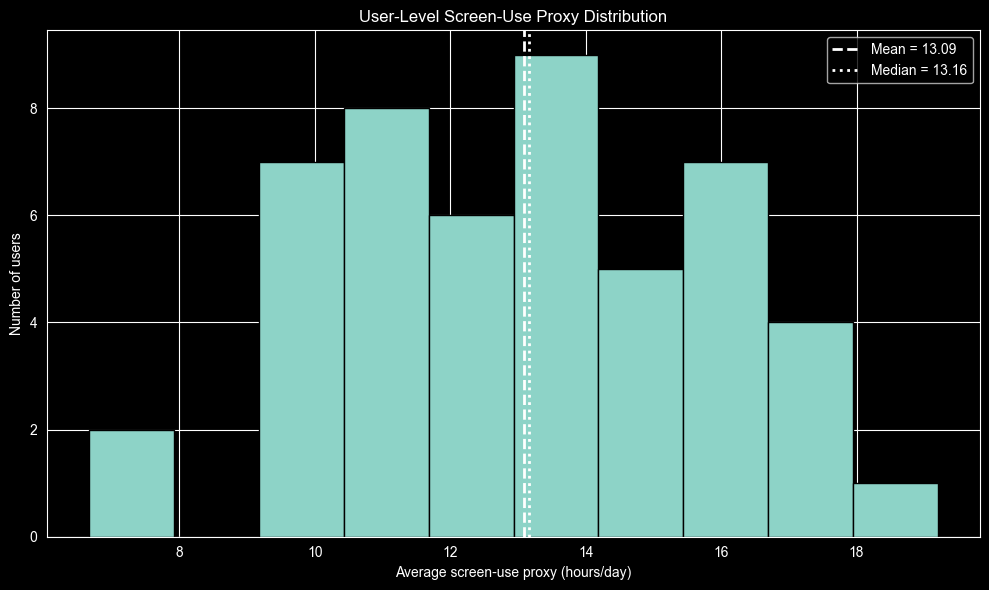

In [16]:
import matplotlib.pyplot as plt

# User-level distribution
user_screen = user_summary["average_screen_use_proxy_hours"].dropna()

plt.figure(figsize=(10, 6))
plt.hist(user_screen, bins=10, edgecolor="black")

plt.axvline(user_screen.mean(), linestyle="--", linewidth=2, label=f"Mean = {user_screen.mean():.2f}")
plt.axvline(user_screen.median(), linestyle=":", linewidth=2, label=f"Median = {user_screen.median():.2f}")

plt.title("User-Level Screen-Use Proxy Distribution")
plt.xlabel("Average screen-use proxy (hours/day)")
plt.ylabel("Number of users")
plt.legend()
plt.tight_layout()

plt.savefig("user_screen_use_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

---

# 15. ✧ Checking for Statistical Outliers

Before creating an outlier-cleaned version of the screen-use proxy data, we first check whether there are statistical outliers.

We do not remove values only because they are low or high.
A value should only be removed if it is statistically unusual compared to the rest of the dataset.

For this, we use the IQR method.

The IQR method uses:

**IQR = Q3 - Q1**

Then it defines possible outliers as values below or above these boundaries:

**Lower boundary = Q1 - 1.5 × IQR**

**Upper boundary = Q3 + 1.5 × IQR**

Values outside these boundaries are considered possible statistical outliers.

This is safer than simply removing the lowest and highest percentages, because it only removes values that are unusually far away from the main distribution.

> In simple terms: this step checks whether the extreme values are truly statistical outliers before removing anything.


In [17]:
# Select the daily screen-use proxy values
daily_screen = daily_summary["screen_use_proxy_hours"].dropna()

# Calculate quartiles and IQR
q1 = daily_screen.quantile(0.25)
q3 = daily_screen.quantile(0.75)
iqr = q3 - q1

# Calculate IQR outlier boundaries
lower_boundary = q1 - 1.5 * iqr
upper_boundary = q3 + 1.5 * iqr

print("IQR outlier check")
print("-----------------")
print("Q1:", round(q1, 2), "hours/day")
print("Q3:", round(q3, 2), "hours/day")
print("IQR:", round(iqr, 2), "hours/day")
print("Lower outlier boundary:", round(lower_boundary, 2), "hours/day")
print("Upper outlier boundary:", round(upper_boundary, 2), "hours/day")

# Identify possible outliers
outlier_mask = (
    (daily_summary["screen_use_proxy_hours"] < lower_boundary) |
    (daily_summary["screen_use_proxy_hours"] > upper_boundary)
)

daily_outliers = daily_summary[outlier_mask].copy()
daily_summary_clean = daily_summary[~outlier_mask].copy()

print("\nOutlier cleaning summary")
print("------------------------")
print("Original participant-days:", len(daily_summary))
print("Detected outlier participant-days:", len(daily_outliers))
print("Cleaned participant-days:", len(daily_summary_clean))

removed_percentage = (len(daily_outliers) / len(daily_summary)) * 100
print("Removed percentage:", round(removed_percentage, 2), "%")

print("\nCleaned daily screen-use proxy summary:")
display(daily_summary_clean["screen_use_proxy_hours"].describe())

IQR outlier check
-----------------
Q1: 8.21 hours/day
Q3: 17.29 hours/day
IQR: 9.08 hours/day
Lower outlier boundary: -5.41 hours/day
Upper outlier boundary: 30.91 hours/day

Outlier cleaning summary
------------------------
Original participant-days: 2571
Detected outlier participant-days: 0
Cleaned participant-days: 2571
Removed percentage: 0.0 %

Cleaned daily screen-use proxy summary:


count    2571.000000
mean       12.744265
std         6.008784
min         0.000000
25%         8.210972
50%        13.103889
75%        17.290278
max        23.990556
Name: screen_use_proxy_hours, dtype: float64

---

# 16. ✧ Checking User-Level Outliers

After checking outliers at the participant-day level, we also check whether any users have unusually high or low average screen-use proxy values.

This check uses each user’s average daily screen-use proxy:

**average_screen_use_proxy_hours**

This is different from the daily outlier check because it looks at users, not individual days.

We use the same IQR method:

**IQR = Q3 - Q1**

**Lower boundary = Q1 - 1.5 × IQR**

**Upper boundary = Q3 + 1.5 × IQR**

Values outside these boundaries would be considered possible user-level outliers.

> In simple terms: this step checks whether any users have unusually extreme average screen-use proxy values.


In [18]:
# Select the user-level average screen-use proxy values
user_screen = user_summary["average_screen_use_proxy_hours"].dropna()

# Calculate quartiles and IQR
user_q1 = user_screen.quantile(0.25)
user_q3 = user_screen.quantile(0.75)
user_iqr = user_q3 - user_q1

# Calculate IQR outlier boundaries
user_lower_boundary = user_q1 - 1.5 * user_iqr
user_upper_boundary = user_q3 + 1.5 * user_iqr

print("User-level IQR outlier check")
print("----------------------------")
print("Q1:", round(user_q1, 2), "hours/day")
print("Q3:", round(user_q3, 2), "hours/day")
print("IQR:", round(user_iqr, 2), "hours/day")
print("Lower outlier boundary:", round(user_lower_boundary, 2), "hours/day")
print("Upper outlier boundary:", round(user_upper_boundary, 2), "hours/day")

# Identify possible user-level outliers
user_outlier_mask = (
    (user_summary["average_screen_use_proxy_hours"] < user_lower_boundary) |
    (user_summary["average_screen_use_proxy_hours"] > user_upper_boundary)
)

user_outliers = user_summary[user_outlier_mask].copy()
user_summary_clean = user_summary[~user_outlier_mask].copy()

print("\nUser-level outlier cleaning summary")
print("-----------------------------------")
print("Original users:", len(user_summary))
print("Detected outlier users:", len(user_outliers))
print("Cleaned users:", len(user_summary_clean))

user_removed_percentage = (len(user_outliers) / len(user_summary)) * 100
print("Removed percentage:", round(user_removed_percentage, 2), "%")

print("\nCleaned user-level screen-use proxy summary:")
display(user_summary_clean["average_screen_use_proxy_hours"].describe())

User-level IQR outlier check
----------------------------
Q1: 11.2 hours/day
Q3: 15.16 hours/day
IQR: 3.96 hours/day
Lower outlier boundary: 5.25 hours/day
Upper outlier boundary: 21.1 hours/day

User-level outlier cleaning summary
-----------------------------------
Original users: 49
Detected outlier users: 0
Cleaned users: 49
Removed percentage: 0.0 %

Cleaned user-level screen-use proxy summary:


count    49.000000
mean     13.088951
std       2.756745
min       6.670293
25%      11.196719
50%      13.159816
75%      15.159940
max      19.196910
Name: average_screen_use_proxy_hours, dtype: float64

---

# 17. ✧ Final Screen-Time Mapping: Screen Exposure Index

The StudentLife dataset does not measure exact phone screen time.

Instead, it provides phone-lock data. From this, we calculate:

**phone_unlocked_proxy_hours**

This variable should not be interpreted as literal active screen time.
Instead, it is used as a relative indicator of screen-related behaviour.

To make this usable for the installation, we create a shared scale:

**screen_exposure_index**

This index ranges from 0 to 100.

For the StudentLife dataset:

**phone_unlocked_proxy_hours → percentile rank → screen_exposure_index**

For the installation:

**user phone screen time from 0 to 6+ hours/day → screen_exposure_index**

This allows both the dataset and the installation input to use the same low-to-very-high screen exposure scale, without claiming that phone-unlocked time equals exact screen time.

| User phone screen time | Screen exposure index | Meaning                        |
| ---------------------- | --------------------: | ------------------------------ |
| 0 hours/day            |                     0 | No phone screen time           |
| 3 hours/day            |                    50 | Moderate smartphone-use anchor |
| 6+ hours/day           |                   100 | Very high screen exposure      |

Values above 6 hours/day are not treated as impossible.
They are capped at the maximum screen-exposure effect in the installation.


In [22]:
# ------------------------------------------------------------
# Final method: screen exposure index
# ------------------------------------------------------------

daily_screen_final = daily_summary.copy()

# Rename the original StudentLife proxy more honestly
daily_screen_final["phone_unlocked_proxy_hours"] = (
    daily_screen_final["screen_use_proxy_hours"]
)

# ------------------------------------------------------------
# 1. StudentLife dataset mapping
# ------------------------------------------------------------
# The StudentLife proxy is converted into a relative percentile-based index.
# Low proxy values become low screen exposure.
# High proxy values become high screen exposure.

proxy = daily_screen_final["phone_unlocked_proxy_hours"]
valid_proxy_count = proxy.notna().sum()

proxy_ranks = proxy.rank(method="average", na_option="keep")

daily_screen_final["screen_exposure_index"] = (
    (proxy_ranks - 1) / (valid_proxy_count - 1) * 100
)

daily_screen_final["screen_exposure_index"] = (
    daily_screen_final["screen_exposure_index"].clip(lower=0, upper=100)
)

# Categorize the exposure index
exposure_bins = [-0.01, 25, 50, 75, 100]
exposure_labels = ["Low", "Moderate", "High", "Very high"]

daily_screen_final["screen_exposure_category"] = pd.cut(
    daily_screen_final["screen_exposure_index"],
    bins=exposure_bins,
    labels=exposure_labels
)

# ------------------------------------------------------------
# 2. Installation mapping
# ------------------------------------------------------------
# User-entered phone screen time is mapped onto the same 0–100 index.
# 0 hours = 0
# 3 hours = 50
# 6+ hours = 100

def phone_screen_time_to_exposure_index(screen_time_hours):
    """
    Convert user-entered phone screen time into the installation screen exposure index.

    This is an installation mapping:
    0 hours/day = 0
    6+ hours/day = 100

    Values above 6 are capped at 100.
    """

    if pd.isna(screen_time_hours):
        return pd.NA

    capped_hours = min(max(screen_time_hours, 0), 6)

    return (capped_hours / 6) * 100

# Example mapping table for the installation
installation_screen_mapping = pd.DataFrame({
    "phone_screen_time_hours": [0, 1.5, 3, 4.5, 6, 8],
    "meaning": [
        "No phone screen time",
        "Low screen exposure",
        "Moderate smartphone-use anchor",
        "High screen exposure",
        "Very high screen exposure",
        "Very high screen exposure, capped"
    ]
})

installation_screen_mapping["screen_exposure_index"] = (
    installation_screen_mapping["phone_screen_time_hours"]
    .apply(phone_screen_time_to_exposure_index)
)

installation_screen_mapping["screen_exposure_category"] = pd.cut(
    installation_screen_mapping["screen_exposure_index"],
    bins=exposure_bins,
    labels=exposure_labels
)

print("Final screen exposure mapping created.")
print("--------------------------------------")
print("StudentLife values are converted into a percentile-based exposure index.")
print("Installation screen-time values are mapped from 0 to 6+ hours/day.")

print("\nStudentLife screen exposure index summary:")
display(daily_screen_final["screen_exposure_index"].describe())

print("\nStudentLife screen exposure category counts:")
display(daily_screen_final["screen_exposure_category"].value_counts().sort_index())

print("\nInstallation screen-time mapping:")
display(installation_screen_mapping)

Final screen exposure mapping created.
--------------------------------------
StudentLife values are converted into a percentile-based exposure index.
Installation screen-time values are mapped from 0 to 6+ hours/day.

StudentLife screen exposure index summary:


count    2571.000000
mean       50.000000
std        28.884361
min         0.038911
25%        25.000000
50%        50.000000
75%        75.000000
max       100.000000
Name: screen_exposure_index, dtype: float64


StudentLife screen exposure category counts:


screen_exposure_category
Low          643
Moderate     643
High         642
Very high    643
Name: count, dtype: int64


Installation screen-time mapping:


,phone_screen_time_hours,meaning,screen_exposure_index,screen_exposure_category
0,0.0,No phone screen time,0.0,Low
1,1.5,Low screen exposure,25.0,Low
2,3.0,Moderate smartphone-use anchor,50.0,Moderate
3,4.5,High screen exposure,75.0,High
4,6.0,Very high screen exposure,100.0,Very high
5,8.0,"Very high screen exposure, capped",100.0,Very high


---

# 18. ✧ Descriptive Statistics for the Final Screen Exposure Mapping

Now we summarize the final screen exposure mapping.

This table keeps both versions of the variable:

| Variable                   | Meaning                                          |
| -------------------------- | ------------------------------------------------ |
| phone_unlocked_proxy_hours | Original StudentLife phone-lock based proxy      |
| screen_exposure_index      | Final mapped screen exposure scale from 0 to 100 |

The original proxy is kept so the data source remains transparent.

The screen exposure index is used for the installation because it avoids treating phone-unlocked time as exact screen time.

In simple terms:

**original StudentLife proxy → relative exposure index → installation-ready variable**


In [23]:
# ------------------------------------------------------------
# Descriptive statistics for the final screen exposure mapping
# ------------------------------------------------------------

raw_proxy = daily_screen_final["phone_unlocked_proxy_hours"]
exposure_index = daily_screen_final["screen_exposure_index"]

final_mapping_stats_table = pd.DataFrame({
    "Statistic": [
        "Count",
        "Minimum",
        "25th percentile",
        "Median",
        "Mean",
        "75th percentile",
        "Maximum",
        "Standard deviation"
    ],
    "Original phone-unlocked proxy": [
        f"{int(raw_proxy.count())} participant-days",
        f"{raw_proxy.min():.2f} hours/day",
        f"{raw_proxy.quantile(0.25):.2f} hours/day",
        f"{raw_proxy.median():.2f} hours/day",
        f"{raw_proxy.mean():.2f} hours/day",
        f"{raw_proxy.quantile(0.75):.2f} hours/day",
        f"{raw_proxy.max():.2f} hours/day",
        f"{raw_proxy.std():.2f} hours/day"
    ],
    "Final screen exposure index": [
        f"{int(exposure_index.count())} participant-days",
        f"{exposure_index.min():.2f}",
        f"{exposure_index.quantile(0.25):.2f}",
        f"{exposure_index.median():.2f}",
        f"{exposure_index.mean():.2f}",
        f"{exposure_index.quantile(0.75):.2f}",
        f"{exposure_index.max():.2f}",
        f"{exposure_index.std():.2f}"
    ],
    "Meaning": [
        "Number of daily records analyzed",
        "Lowest observed value",
        "25% of daily records were at or below this value",
        "Middle daily value",
        "Average daily value",
        "75% of daily records were at or below this value",
        "Highest observed value",
        "Spread between daily values"
    ]
})

display(final_mapping_stats_table)

print("Screen exposure category counts:")
exposure_category_table = (
    daily_screen_final["screen_exposure_category"]
    .value_counts()
    .sort_index()
    .reset_index()
)

exposure_category_table.columns = ["Screen exposure category", "Number of participant-days"]

exposure_category_table["Percentage"] = (
    exposure_category_table["Number of participant-days"] /
    exposure_category_table["Number of participant-days"].sum() * 100
).round(2)

display(exposure_category_table)

,Statistic,Original phone-unlocked proxy,Final screen exposure index,Meaning
0,Count,2571 participant-days,2571 participant-days,Number of daily records analyzed
1,Minimum,0.00 hours/day,0.04,Lowest observed value
2,25th percentile,8.21 hours/day,25.00,25% of daily records were at or below this value
3,Median,13.10 hours/day,50.00,Middle daily value
4,Mean,12.74 hours/day,50.00,Average daily value
5,75th percentile,17.29 hours/day,75.00,75% of daily records were at or below this value
6,Maximum,23.99 hours/day,100.00,Highest observed value
7,Standard deviation,6.01 hours/day,28.88,Spread between daily values


Screen exposure category counts:


,Screen exposure category,Number of participant-days,Percentage
0,Low,643,25.01
1,Moderate,643,25.01
2,High,642,24.97
3,Very high,643,25.01


---

# 19. ✧ Continuous Screen Exposure Mapping

The screen exposure index should stay continuous.

This means that the data is not reduced into only four categories.

Instead, every participant-day receives its own value between 0 and 100.

For the StudentLife dataset:

**phone_unlocked_proxy_hours → continuous screen_exposure_index**

For the installation:

**user phone screen time from 0 to 6+ hours/day → continuous screen_exposure_index**

The categories such as low, moderate, high, and very high are only used as an interpretation guide.
They are not used to replace the continuous data.

In simple terms:

**the model uses numbers, while the labels help humans understand those numbers.**


In [24]:
# ------------------------------------------------------------
# Continuous screen exposure mapping
# ------------------------------------------------------------

daily_screen_final = daily_summary.copy()

# Keep the original StudentLife proxy, but rename it honestly
daily_screen_final["phone_unlocked_proxy_hours"] = (
    daily_screen_final["screen_use_proxy_hours"]
)

# ------------------------------------------------------------
# 1. Continuous StudentLife mapping
# ------------------------------------------------------------
# Convert the phone-unlocked proxy into a continuous 0–100 exposure index.
# This uses the relative position of each value in the StudentLife distribution.
# Lowest observed proxy value = 0
# Highest observed proxy value = 100

proxy = daily_screen_final["phone_unlocked_proxy_hours"]

proxy_rank = proxy.rank(method="average", na_option="keep")

daily_screen_final["screen_exposure_index"] = (
    (proxy_rank - proxy_rank.min()) /
    (proxy_rank.max() - proxy_rank.min()) *
    100
)

daily_screen_final["screen_exposure_index"] = (
    daily_screen_final["screen_exposure_index"].clip(lower=0, upper=100)
)

# ------------------------------------------------------------
# 2. Continuous installation mapping
# ------------------------------------------------------------
# User-entered phone screen time is mapped continuously from 0 to 100.
# 0 hours/day = 0
# 3 hours/day = 50
# 6+ hours/day = 100
# Values above 6 are capped at 100.

def phone_screen_time_to_exposure_index(screen_time_hours):
    """
    Convert user-entered phone screen time into the installation screen exposure index.

    This is a continuous installation mapping:
    0 hours/day = 0
    3 hours/day = 50
    6+ hours/day = 100

    Values above 6 are capped at 100.
    """

    if pd.isna(screen_time_hours):
        return pd.NA

    capped_hours = min(max(screen_time_hours, 0), 6)

    return (capped_hours / 6) * 100

# Example guide for the installation.
# This is only a guide, not a grouping of the real dataset.
installation_screen_mapping_guide = pd.DataFrame({
    "phone_screen_time_hours": [0, 1, 2, 3, 4, 5, 6, 8],
    "screen_exposure_index": [
        phone_screen_time_to_exposure_index(value)
        for value in [0, 1, 2, 3, 4, 5, 6, 8]
    ],
    "symbolic_meaning": [
        "No phone screen time",
        "Very low exposure",
        "Low exposure",
        "Moderate smartphone-use anchor",
        "Moderately high exposure",
        "High exposure",
        "Very high exposure",
        "Very high exposure, capped"
    ]
})

print("Continuous screen exposure mapping created.")
print("-------------------------------------------")
print("The real dataset is mapped onto a continuous 0–100 index.")
print("The symbolic labels are only used as an interpretation guide.")

print("\nStudentLife continuous screen exposure index summary:")
display(daily_screen_final["screen_exposure_index"].describe())

print("\nInstallation continuous mapping guide:")
display(installation_screen_mapping_guide)

Continuous screen exposure mapping created.
-------------------------------------------
The real dataset is mapped onto a continuous 0–100 index.
The symbolic labels are only used as an interpretation guide.

StudentLife continuous screen exposure index summary:


count    2571.000000
mean       49.980537
std        28.895605
min         0.000000
25%        24.970806
50%        49.980537
75%        74.990269
max       100.000000
Name: screen_exposure_index, dtype: float64


Installation continuous mapping guide:


,phone_screen_time_hours,screen_exposure_index,symbolic_meaning
0,0,0.000000,No phone screen time
1,1,16.666667,Very low exposure
2,2,33.333333,Low exposure
3,3,50.000000,Moderate smartphone-use anchor
4,4,66.666667,Moderately high exposure
5,5,83.333333,High exposure
6,6,100.000000,Very high exposure
7,8,100.000000,"Very high exposure, capped"


---

# 20. ✧ Graphing the Final Screen-Time Mapping

Now we create a graph for the final installation screen-time mapping.

The installation uses real phone screen time as input.

This input is mapped onto a continuous screen exposure index from 0 to 100.

The mapping is:

| Phone screen time | Screen exposure index |
| ----------------- | --------------------: |
| 0 hours/day       |                     0 |
| 3 hours/day       |                    50 |
| 6+ hours/day      |                   100 |

Values above 6 hours/day are capped at 100.

This graph shows the installation mapping, not the raw StudentLife proxy distribution.


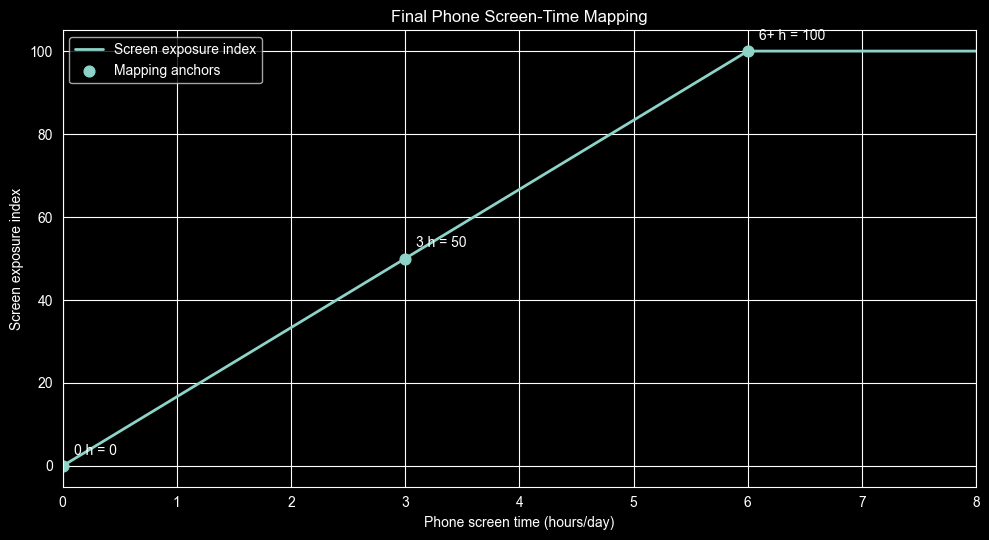

Graph saved to:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs\screen_time_to_exposure_index_mapping.png


In [25]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Make sure the graph folder exists
# ------------------------------------------------------------

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

GRAPH_DIR = PROJECT_DIR / "Graphs"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Continuous installation mapping
# ------------------------------------------------------------

def phone_screen_time_to_exposure_index(screen_time_hours):
    """
    Convert user-entered phone screen time into the installation screen exposure index.

    0 hours/day = 0
    3 hours/day = 50
    6+ hours/day = 100

    Values above 6 are capped at 100.
    """

    capped_hours = min(max(screen_time_hours, 0), 6)

    return (capped_hours / 6) * 100

# Create example screen-time values from 0 to 8 hours
screen_time_values = np.linspace(0, 8, 200)

# Convert each value into the exposure index
exposure_index_values = [
    phone_screen_time_to_exposure_index(value)
    for value in screen_time_values
]

# ------------------------------------------------------------
# Create graph
# ------------------------------------------------------------

plt.figure(figsize=(10, 5.5))

plt.plot(
    screen_time_values,
    exposure_index_values,
    linewidth=2,
    label="Screen exposure index"
)

# Mark important anchor points
anchor_hours = [0, 3, 6]
anchor_index = [0, 50, 100]

plt.scatter(
    anchor_hours,
    anchor_index,
    s=60,
    label="Mapping anchors"
)

for x, y, label in [
    (0, 0, "0 h = 0"),
    (3, 50, "3 h = 50"),
    (6, 100, "6+ h = 100")
]:
    plt.annotate(
        label,
        (x, y),
        textcoords="offset points",
        xytext=(8, 8),
        ha="left"
    )

plt.title("Final Phone Screen-Time Mapping")
plt.xlabel("Phone screen time (hours/day)")
plt.ylabel("Screen exposure index")
plt.ylim(-5, 105)
plt.xlim(0, 8)
plt.legend()
plt.tight_layout()

# Save graph
screen_mapping_graph_path = GRAPH_DIR / "screen_time_to_exposure_index_mapping.png"
plt.savefig(screen_mapping_graph_path, dpi=300, bbox_inches="tight")

plt.show()

print("Graph saved to:")
print(screen_mapping_graph_path)

---

# ✧ Saving a Checkpoint Before Closing the Notebook

Before closing the notebook, we save the important processed dataframes as checkpoint files.

This is useful because Jupyter notebooks do not always keep Python variables alive after the notebook is closed or the kernel is stopped.

For example, variables such as:

| Variable | Meaning |
|---|---|
| phonelock_clean | Cleaned phone-lock interval data |
| daily_lock_pieces | Phone-lock intervals split by day |
| daily_summary | Daily locked time and screen-use proxy per participant-day |

The notebook output may still be visible after reopening the file, but the actual Python variables may disappear from memory.

To avoid having to rerun the whole analysis from the beginning, this checkpoint saves the processed data as .pkl files inside:

data/checkpoints

Later, these files can be loaded again to continue the analysis from the same point.

> In simple terms: this step saves our progress before leaving the notebook.

In [19]:
from pathlib import Path
import pandas as pd

CHECKPOINT_DIR = Path("data/checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

if "phonelock_clean" in globals():
    phonelock_clean.to_pickle(CHECKPOINT_DIR / "phonelock_clean.pkl")
    print("Saved phonelock_clean")

if "daily_lock_pieces" in globals():
    daily_lock_pieces.to_pickle(CHECKPOINT_DIR / "daily_lock_pieces.pkl")
    print("Saved daily_lock_pieces")

if "daily_summary" in globals():
    daily_summary.to_pickle(CHECKPOINT_DIR / "daily_summary.pkl")
    print("Saved daily_summary")

print("Checkpoint saving finished.")

Saved phonelock_clean
Saved daily_lock_pieces
Saved daily_summary
Checkpoint saving finished.


---

# ✧ Loading a Saved Checkpoint

This step reloads the processed dataframes that were saved earlier.

Jupyter notebooks can save visible outputs, but they do not always keep Python variables alive after the notebook is closed or the kernel is stopped.

Because of this, we saved the important processed tables as .pkl checkpoint files.

In this step, we load them back into memory so the analysis can continue without restarting from the beginning.

The checkpoint files are stored inside:

data/checkpoints

The main variables restored in this step are:

| Variable | Meaning |
|---|---|
| phonelock_clean | Cleaned phone-lock interval data |
| daily_lock_pieces | Phone-lock intervals split into daily pieces |
| daily_summary | Daily locked time and screen-use proxy per participant-day |

After running this cell, the notebook can continue from the saved point instead of re-downloading and re-processing the dataset.

> In simple terms: this step opens our saved progress and brings the analysis back to life.

In [20]:
from pathlib import Path
import pandas as pd

CHECKPOINT_DIR = Path("data/checkpoints")

if (CHECKPOINT_DIR / "phonelock_clean.pkl").exists():
    phonelock_clean = pd.read_pickle(CHECKPOINT_DIR / "phonelock_clean.pkl")
    print("Loaded phonelock_clean")

if (CHECKPOINT_DIR / "daily_lock_pieces.pkl").exists():
    daily_lock_pieces = pd.read_pickle(CHECKPOINT_DIR / "daily_lock_pieces.pkl")
    print("Loaded daily_lock_pieces")

if (CHECKPOINT_DIR / "daily_summary.pkl").exists():
    daily_summary = pd.read_pickle(CHECKPOINT_DIR / "daily_summary.pkl")
    print("Loaded daily_summary")

print("Checkpoint loading finished.")

Loaded phonelock_clean
Loaded daily_lock_pieces
Loaded daily_summary
Checkpoint loading finished.
